<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/5_CNN_Buiilding_and_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!export KAGGLE_API_TOKEN=KGAT_ec4a2184cf5b49686c88d99226b3a340

In [2]:
!mkdir -p ~/.kaggle && echo KGAT_ec4a2184cf5b49686c88d99226b3a340 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_851dfe675ddff41bb9613a44badd64be"

In [4]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [5]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:27<00:00, 41.8MB/s]



In [6]:
!unzip /content/dogsvscats.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

##Installing all the libraries

In [7]:
!pip3 install tensorflow numpy matplotlib lib keras

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers,models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

In [9]:
cat_directory_path='/content/catsvsdogs/train/cats'
dog_directory_path='/content/catsvsdogs/train/dogs'

In [10]:
os.listdir(cat_directory_path)

['cat.852.jpg',
 'cat.31.jpg',
 'cat.1564.jpg',
 'cat.3894.jpg',
 'cat.1679.jpg',
 'cat.1626.jpg',
 'cat.1897.jpg',
 'cat.6504.jpg',
 'cat.6888.jpg',
 'cat.9118.jpg',
 'cat.6721.jpg',
 'cat.10754.jpg',
 'cat.200.jpg',
 'cat.8891.jpg',
 'cat.3210.jpg',
 'cat.9052.jpg',
 'cat.692.jpg',
 'cat.4590.jpg',
 'cat.863.jpg',
 'cat.8043.jpg',
 'cat.7076.jpg',
 'cat.9175.jpg',
 'cat.12296.jpg',
 'cat.515.jpg',
 'cat.5482.jpg',
 'cat.4535.jpg',
 'cat.4383.jpg',
 'cat.10173.jpg',
 'cat.456.jpg',
 'cat.9995.jpg',
 'cat.4260.jpg',
 'cat.2340.jpg',
 'cat.10997.jpg',
 'cat.925.jpg',
 'cat.254.jpg',
 'cat.3975.jpg',
 'cat.2351.jpg',
 'cat.8454.jpg',
 'cat.4422.jpg',
 'cat.11321.jpg',
 'cat.10053.jpg',
 'cat.10904.jpg',
 'cat.10112.jpg',
 'cat.10161.jpg',
 'cat.9713.jpg',
 'cat.521.jpg',
 'cat.3747.jpg',
 'cat.11983.jpg',
 'cat.7946.jpg',
 'cat.8733.jpg',
 'cat.1120.jpg',
 'cat.2969.jpg',
 'cat.4268.jpg',
 'cat.9331.jpg',
 'cat.1802.jpg',
 'cat.8794.jpg',
 'cat.11198.jpg',
 'cat.7226.jpg',
 'cat.1700.jpg

In [11]:
len(os.listdir(cat_directory_path)),len(os.listdir(dog_directory_path))

(10000, 10000)

## Loading images
cv2/numpy/PIL image

array([[[101, 120, 155],
        [102, 121, 156],
        [102, 121, 156],
        ...,
        [117, 136, 174],
        [114, 133, 171],
        [110, 129, 167]],

       [[102, 121, 156],
        [103, 122, 157],
        [104, 123, 158],
        ...,
        [119, 138, 176],
        [116, 135, 173],
        [112, 131, 169]],

       [[105, 124, 159],
        [106, 125, 160],
        [106, 125, 160],
        ...,
        [121, 140, 178],
        [118, 137, 175],
        [114, 133, 171]],

       ...,

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 32,  41,  61],
        [ 34,  45,  65],
        [ 38,  49,  71]],

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 30,  37,  56],
        [ 31,  40,  60],
        [ 35,  43,  66]],

       [[ 53,  72,  99],
        [ 53,  72,  99],
        [ 51,  70,  97],
        ...,
        [ 25,  31,  50],
        [ 28,  35,  54],
        [ 32,  39,  59]]], dtype=uint8)
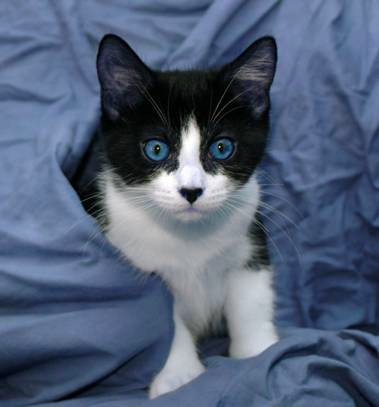

In [12]:
cat_img='/content/catsvsdogs/train/cats/cat.1002.jpg'

import cv2
img=cv2.imread(cat_img)
img

In [13]:
print(img)

[[[101 120 155]
  [102 121 156]
  [102 121 156]
  ...
  [117 136 174]
  [114 133 171]
  [110 129 167]]

 [[102 121 156]
  [103 122 157]
  [104 123 158]
  ...
  [119 138 176]
  [116 135 173]
  [112 131 169]]

 [[105 124 159]
  [106 125 160]
  [106 125 160]
  ...
  [121 140 178]
  [118 137 175]
  [114 133 171]]

 ...

 [[ 53  72  99]
  [ 52  71  98]
  [ 51  70  97]
  ...
  [ 32  41  61]
  [ 34  45  65]
  [ 38  49  71]]

 [[ 53  72  99]
  [ 52  71  98]
  [ 51  70  97]
  ...
  [ 30  37  56]
  [ 31  40  60]
  [ 35  43  66]]

 [[ 53  72  99]
  [ 53  72  99]
  [ 51  70  97]
  ...
  [ 25  31  50]
  [ 28  35  54]
  [ 32  39  59]]]


## Breaking datset

Keras documentation for ImageDataGenerator
https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator

In [14]:
base_dir='/content/catsvsdogs/train'

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [15]:
# Using 20% of data for training
#flow_from_directory-> for directory dataset
#flow_from_dataframe-> for dataframe dataset

train_generator=train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',                         # Binary-> only 2 classes cats and dogs
    subset='training')

Found 16000 images belonging to 2 classes.


20k images                   
80%   first 16000 images                 
20%   and now 4000 images

In [16]:
validation_generator=train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    subset='validation',
    shuffle=False                     # Disable shuffling for validation data
)

Found 4000 images belonging to 2 classes.


In [17]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

## Building Model

In [18]:
model=models.Sequential([
    #layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    #Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    #Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    #Layer 2
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# None(0) -> denotes the batch size

# Sigmoid -> bianry classification
# Softmax -> MultiClass Classification
# Regression?

In [20]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [21]:
history=model.fit(train_generator,
          epochs=10,
          validation_data=validation_generator)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.5605 - loss: 0.6774 - val_accuracy: 0.6555 - val_loss: 0.6244
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.6951 - loss: 0.5690 - val_accuracy: 0.7595 - val_loss: 0.5087
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.7819 - loss: 0.4598 - val_accuracy: 0.7705 - val_loss: 0.4637
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8298 - loss: 0.3765 - val_accuracy: 0.8342 - val_loss: 0.3775
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8627 - loss: 0.3148 - val_accuracy: 0.8482 - val_loss: 0.3470
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.8831 - loss: 0.2696 - val_accuracy: 0.8438 - val_loss: 0.3683
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.9093 - loss: 0.2167 - val_accuracy: 0.8685 - val_loss: 0.3330
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.9287 - loss: 0.1744 - 

In [22]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

print(acc, val_acc, loss, val_loss)

[0.5605000257492065, 0.695062518119812, 0.7818750143051147, 0.8297500014305115, 0.8626875281333923, 0.883062481880188, 0.909250020980835, 0.9286875128746033, 0.9470624923706055, 0.9628124833106995] [0.6554999947547913, 0.7595000267028809, 0.7705000042915344, 0.8342499732971191, 0.8482499718666077, 0.84375, 0.8684999942779541, 0.8602499961853027, 0.8585000038146973, 0.8642500042915344] [0.677402913570404, 0.5689775347709656, 0.45984429121017456, 0.3764970898628235, 0.31478357315063477, 0.2696203887462616, 0.2166540026664734, 0.1744115948677063, 0.1273692101240158, 0.09820221364498138] [0.6244237422943115, 0.508722186088562, 0.46372824907302856, 0.37750327587127686, 0.34701478481292725, 0.3682593107223511, 0.33298346400260925, 0.35950905084609985, 0.4296477735042572, 0.4519994258880615]


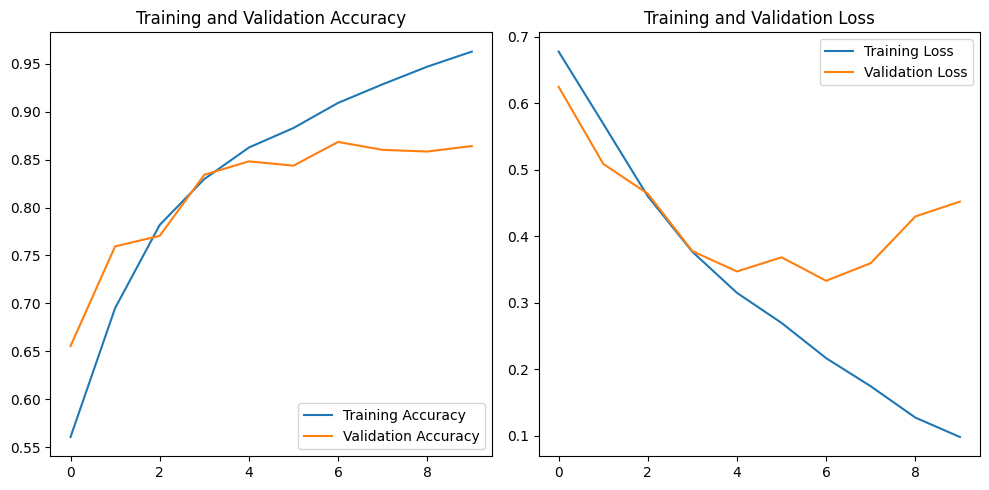

In [23]:
epochs_range=range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Testing and Inference

In [24]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_dir='/content/catsvsdogs/test'

test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    shuffle=False)

Found 5000 images belonging to 2 classes.


In [25]:
# Evaluating the model

test_loss, test_accuracy = model.evaluate(test_generator,steps=len(test_generator))

print(f'Test Loss : {test_loss}')
print(f'Test Accuracy : {test_accuracy}')

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8672 - loss: 0.4584
Test Loss : 0.4583849608898163
Test Accuracy : 0.8672000169754028


## Confusion Matrix

In [26]:
probabilities=model.predict(test_generator)
probabilities

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step


array([[2.1724247e-09],
       [2.3772225e-06],
       [1.2070884e-05],
       ...,
       [9.8028940e-01],
       [9.0377653e-01],
       [6.0721970e-01]], dtype=float32)

In [27]:
predicted_classes=(probabilities>0.5).astype(int).squeeze()
predicted_classes

array([0, 0, 0, ..., 1, 1, 1])

In [28]:
test_generator.class_indices

{'cats': 0, 'dogs': 1}

In [29]:
# For actual class labels

class_labels=list(test_generator.class_indices.keys())
predicted_labels=[class_labels[i] for i in predicted_classes]

In [30]:
# Get the true labels from test generator
true_classes=test_generator.classes

# Generation the confusion matrix
cm=confusion_matrix(true_classes, predicted_classes)
cm

array([[2233,  267],
       [ 397, 2103]])

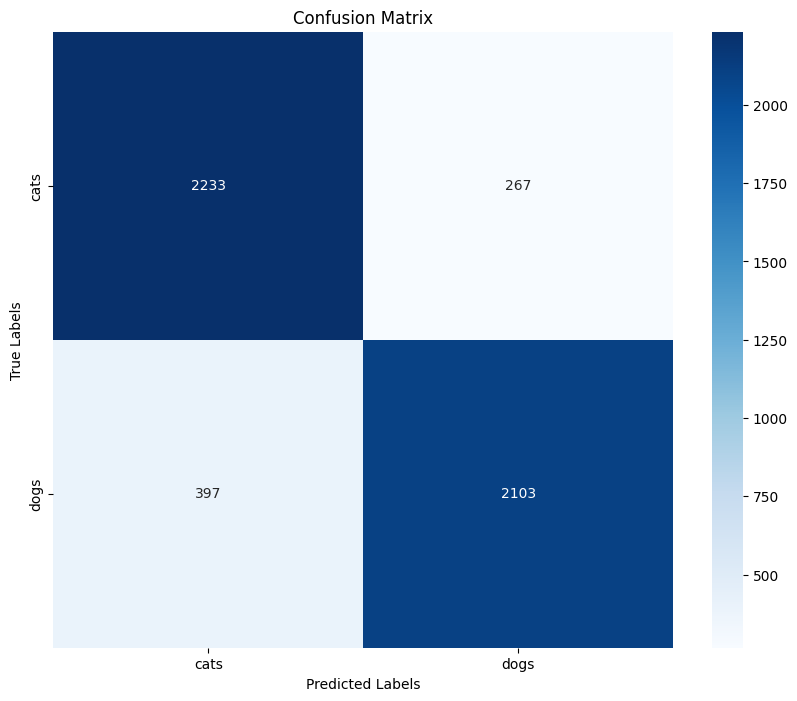

In [31]:
# Plotting with Seaborn
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Single Image Predictiom

In [32]:
test_image='/content/catsvsdogs/test/cats/cat.10000.jpg'

img=load_img(test_image, target_size=(150,150))         # Resizing the image

img_array=img_to_array(img)                             # Converting to array
print(img_array.shape)
img_array=np.expand_dims(img_array,axis=0)              # Adding Batch dimension
img_array/=255

img_array.shape

(150, 150, 3)


(1, 150, 150, 3)

In [33]:
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step


array([[2.3772225e-06]], dtype=float32)

## Creating the function

In [34]:
def make_prediction(image_path):
    img=load_img(img_path, target_size=(150,150))
    img_array=img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array/=255

    prediction=model.predict(img_array)
    print('Prediction:', prediction)

    # Original Shape:
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    #Prediction
    plt.subplot(1,2,2)
    if prediction[0][0]>0.5:
        plt.title('Predicted : Dog')
    else:
        plt.title('Predicted  : Cat')
    plt.imshow(img)
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: [[0.9740205]]


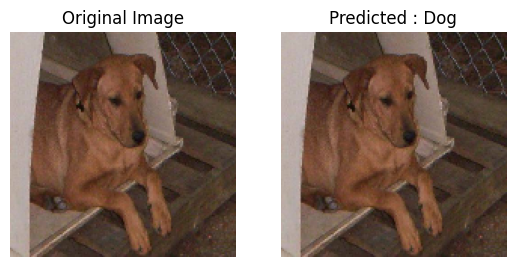

In [35]:
# Load and Preprocess the data
img_path ='/content/catsvsdogs/test/dogs/dog.100.jpg'
make_prediction(img_path)